In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap
import networkx as nx

In [2]:
df = pd.read_csv("clusters_candidates.tsv", sep="\t")

def extract_phylum(tax):
    for x in tax.split(";"):
        if x.startswith("p__"):
            return x.replace("p__", "")
    return "Unknown"

df["Phylum"] = df["taxonomy"].apply(extract_phylum)

In [3]:
import pandas as pd

df = pd.read_csv("clusters_candidates.tsv", sep="\t")

def parse_taxonomy(tax):
    ranks = {
        "Domain": "Unknown",
        "Phylum": "Unknown",
        "Class": "Unknown",
        "Order": "Unknown",
        "Family": "Unknown",
        "Genus": "Unknown",
        "Species": "Unknown"
    }
    
    if pd.isna(tax):
        return pd.Series(ranks)
    
    for x in tax.split(";"):
        if x.startswith("d__"):
            ranks["Domain"] = x.replace("d__", "")
        elif x.startswith("p__"):
            ranks["Phylum"] = x.replace("p__", "")
        elif x.startswith("c__"):
            ranks["Class"] = x.replace("c__", "")
        elif x.startswith("o__"):
            ranks["Order"] = x.replace("o__", "")
        elif x.startswith("f__"):
            ranks["Family"] = x.replace("f__", "")
        elif x.startswith("g__"):
            ranks["Genus"] = x.replace("g__", "")
        elif x.startswith("s__"):
            ranks["Species"] = x.replace("s__", "")
    
    return pd.Series(ranks)

tax_table = df["taxonomy"].apply(parse_taxonomy)

df = pd.concat([df, tax_table], axis=1)

In [4]:
df.head()


,MAG,query,target,identity,aln_len,evalue,bitscore,product,contig,start,...,distance,cluster,cluster_size,Domain,Phylum,Class,Order,Family,Genus,Species
0,GCA_902754875.1,EJF39103.1,GCA_902754875.1_KMPMIM_00214,34.9,364,5.160000e-64,212.0,hypothetical protein,CACVLA010000002.1,26588,...,NaN,14,4,Bacteria,Bacillota,Clostridia,Oscillospirales,Oscillospiraceae,Faecousia,Faecousia sp900315595
1,GCA_902754875.1,EJF39089.1,GCA_902754875.1_KMPMIM_00215,57.6,85,4.140000e-28,103.0,hypothetical protein,CACVLA010000002.1,27675,...,667.0,14,4,Bacteria,Bacillota,Clostridia,Oscillospirales,Oscillospiraceae,Faecousia,Faecousia sp900315595
2,GCA_902754875.1,EJF39090.1,GCA_902754875.1_KMPMIM_00216,55.1,254,7.350000e-88,267.0,hypothetical protein,CACVLA010000002.1,27946,...,523.0,14,4,Bacteria,Bacillota,Clostridia,Oscillospirales,Oscillospiraceae,Faecousia,Faecousia sp900315595
3,GCA_902754875.1,AYG21321.1,GCA_902754875.1_KMPMIM_00222,24.5,277,1.160000e-05,50.4,hypothetical protein,CACVLA010000002.1,32567,...,4634.5,14,4,Bacteria,Bacillota,Clostridia,Oscillospirales,Oscillospiraceae,Faecousia,Faecousia sp900315595
4,GCA_902754875.1,EJF39099.1,GCA_902754875.1_KMPMIM_01959,50.6,265,7.450000e-85,259.0,Transketolase 1,CACVLA010000043.1,5168,...,NaN,27,2,Bacteria,Bacillota,Clostridia,Oscillospirales,Oscillospiraceae,Faecousia,Faecousia sp900315595


In [5]:
tax_cols = ["Domain", "Phylum", "Class", "Order", "Family", "Genus", "Species"]

df_unique = df.drop_duplicates(subset=["MAG", "Gene"])[["MAG", "Gene"] + tax_cols]

df_unique.head()

,MAG,Gene,Domain,Phylum,Class,Order,Family,Genus,Species
0,GCA_902754875.1,sqwF,Bacteria,Bacillota,Clostridia,Oscillospirales,Oscillospiraceae,Faecousia,Faecousia sp900315595
1,GCA_902754875.1,sqwI,Bacteria,Bacillota,Clostridia,Oscillospirales,Oscillospiraceae,Faecousia,Faecousia sp900315595
2,GCA_902754875.1,sqwH,Bacteria,Bacillota,Clostridia,Oscillospirales,Oscillospiraceae,Faecousia,Faecousia sp900315595
3,GCA_902754875.1,yihV,Bacteria,Bacillota,Clostridia,Oscillospirales,Oscillospiraceae,Faecousia,Faecousia sp900315595
4,GCA_902754875.1,sqwG,Bacteria,Bacillota,Clostridia,Oscillospirales,Oscillospiraceae,Faecousia,Faecousia sp900315595


In [6]:
#Построить матрицу присутствия
presence_matrix = pd.crosstab(
    df_unique["MAG"],
    df_unique["Gene"]
)

presence_matrix.head()

Gene,sedA,sedB,sedC,sedD,slaB,sqgA,sqiA,sqiK,squD,squF,...,sqwI,sqwK,sqwL,ssuE,yihQ,yihR,yihS,yihT,yihU,yihV
MAG,,,,,,,,,,,,,,,,,,,,,
GCA_902751235.1,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
GCA_902754855.1,1,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
GCA_902754875.1,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
GCA_902754915.1,0,0,0,0,0,0,1,1,0,0,...,1,0,0,0,0,0,0,0,0,0
GCA_902754935.1,0,0,0,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


In [7]:
tax_cols = ["Domain", "Phylum", "Class", "Order", "Family", "Genus", "Species"]

presence_matrix = presence_matrix.drop(columns=tax_cols, errors="ignore")

mag_to_tax = df_unique.drop_duplicates("MAG").set_index("MAG")[tax_cols]

presence_matrix = presence_matrix.join(mag_to_tax, how="left")

presence_matrix.head()

,sedA,sedB,sedC,sedD,slaB,sqgA,sqiA,sqiK,squD,squF,...,yihT,yihU,yihV,Domain,Phylum,Class,Order,Family,Genus,Species
MAG,,,,,,,,,,,,,,,,,,,,,
GCA_902751235.1,0,0,0,0,0,0,0,1,0,0,...,0,0,0,Bacteria,Bacillota,Clostridia,Christensenellales,RUG350,RUG350,RUG350 sp900315995
GCA_902754855.1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,P3,Colimorpha,Colimorpha sp900316055
GCA_902754875.1,0,0,0,0,0,0,0,0,0,0,...,0,0,1,Bacteria,Bacillota,Clostridia,Oscillospirales,Oscillospiraceae,Faecousia,Faecousia sp900315595
GCA_902754915.1,0,0,0,0,0,0,1,1,0,0,...,0,0,0,Bacteria,Bacillota,Clostridia,Oscillospirales,Oscillospiraceae,CAG-103,CAG-103 sp900317905
GCA_902754935.1,0,0,0,0,0,1,0,0,0,0,...,0,0,0,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Prevotella,Prevotella sp900314755


In [8]:
tax_cols = ["Domain", "Phylum", "Class", "Order", "Family", "Genus", "Species"]

# genes only
X = presence_matrix.drop(columns=tax_cols, errors="ignore")

# обязательно приводим к числам
X = X.apply(pd.to_numeric, errors="coerce").fillna(0).astype(int)

# taxonomy отдельно
tax = presence_matrix[tax_cols].copy()

/home/arseniy/miniconda3/envs/ml/lib/python3.11/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
/home/arseniy/miniconda3/envs/ml/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


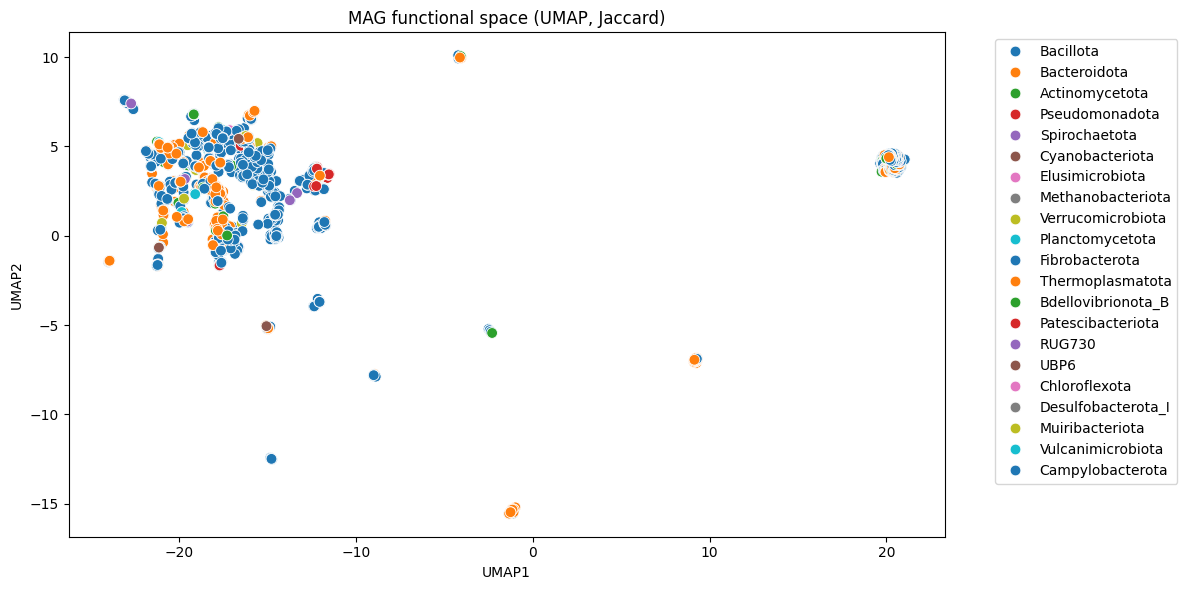

In [9]:
#UMAP с метрикой Жаккара
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="jaccard",
    random_state=42
)

coords = reducer.fit_transform(X)

plot_df = tax[["Phylum"]].copy()
plot_df["UMAP1"] = coords[:, 0]
plot_df["UMAP2"] = coords[:, 1]

plt.figure(figsize=(12,6))

ax = sns.scatterplot(
    data=plot_df,
    x="UMAP1",
    y="UMAP2",
    hue="Phylum",
    palette="tab10",
    s=60
)

plt.title("MAG functional space (UMAP, Jaccard)")

plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.tight_layout()
plt.show()

In [10]:
# binary matrix (ускоряет dot-product)
X_bin = X.astype(bool).astype(int)

# co-occurrence
intersection = X_bin.T @ X_bin

# counts
counts = X_bin.sum().values

# union
union = np.add.outer(counts, counts) - intersection.values
union = union.astype(float)
union[union == 0] = np.nan

# jaccard
jaccard = pd.DataFrame(
    intersection.values / union,
    index=X.columns,
    columns=X.columns
).fillna(0)

np.fill_diagonal(jaccard.values, 0)

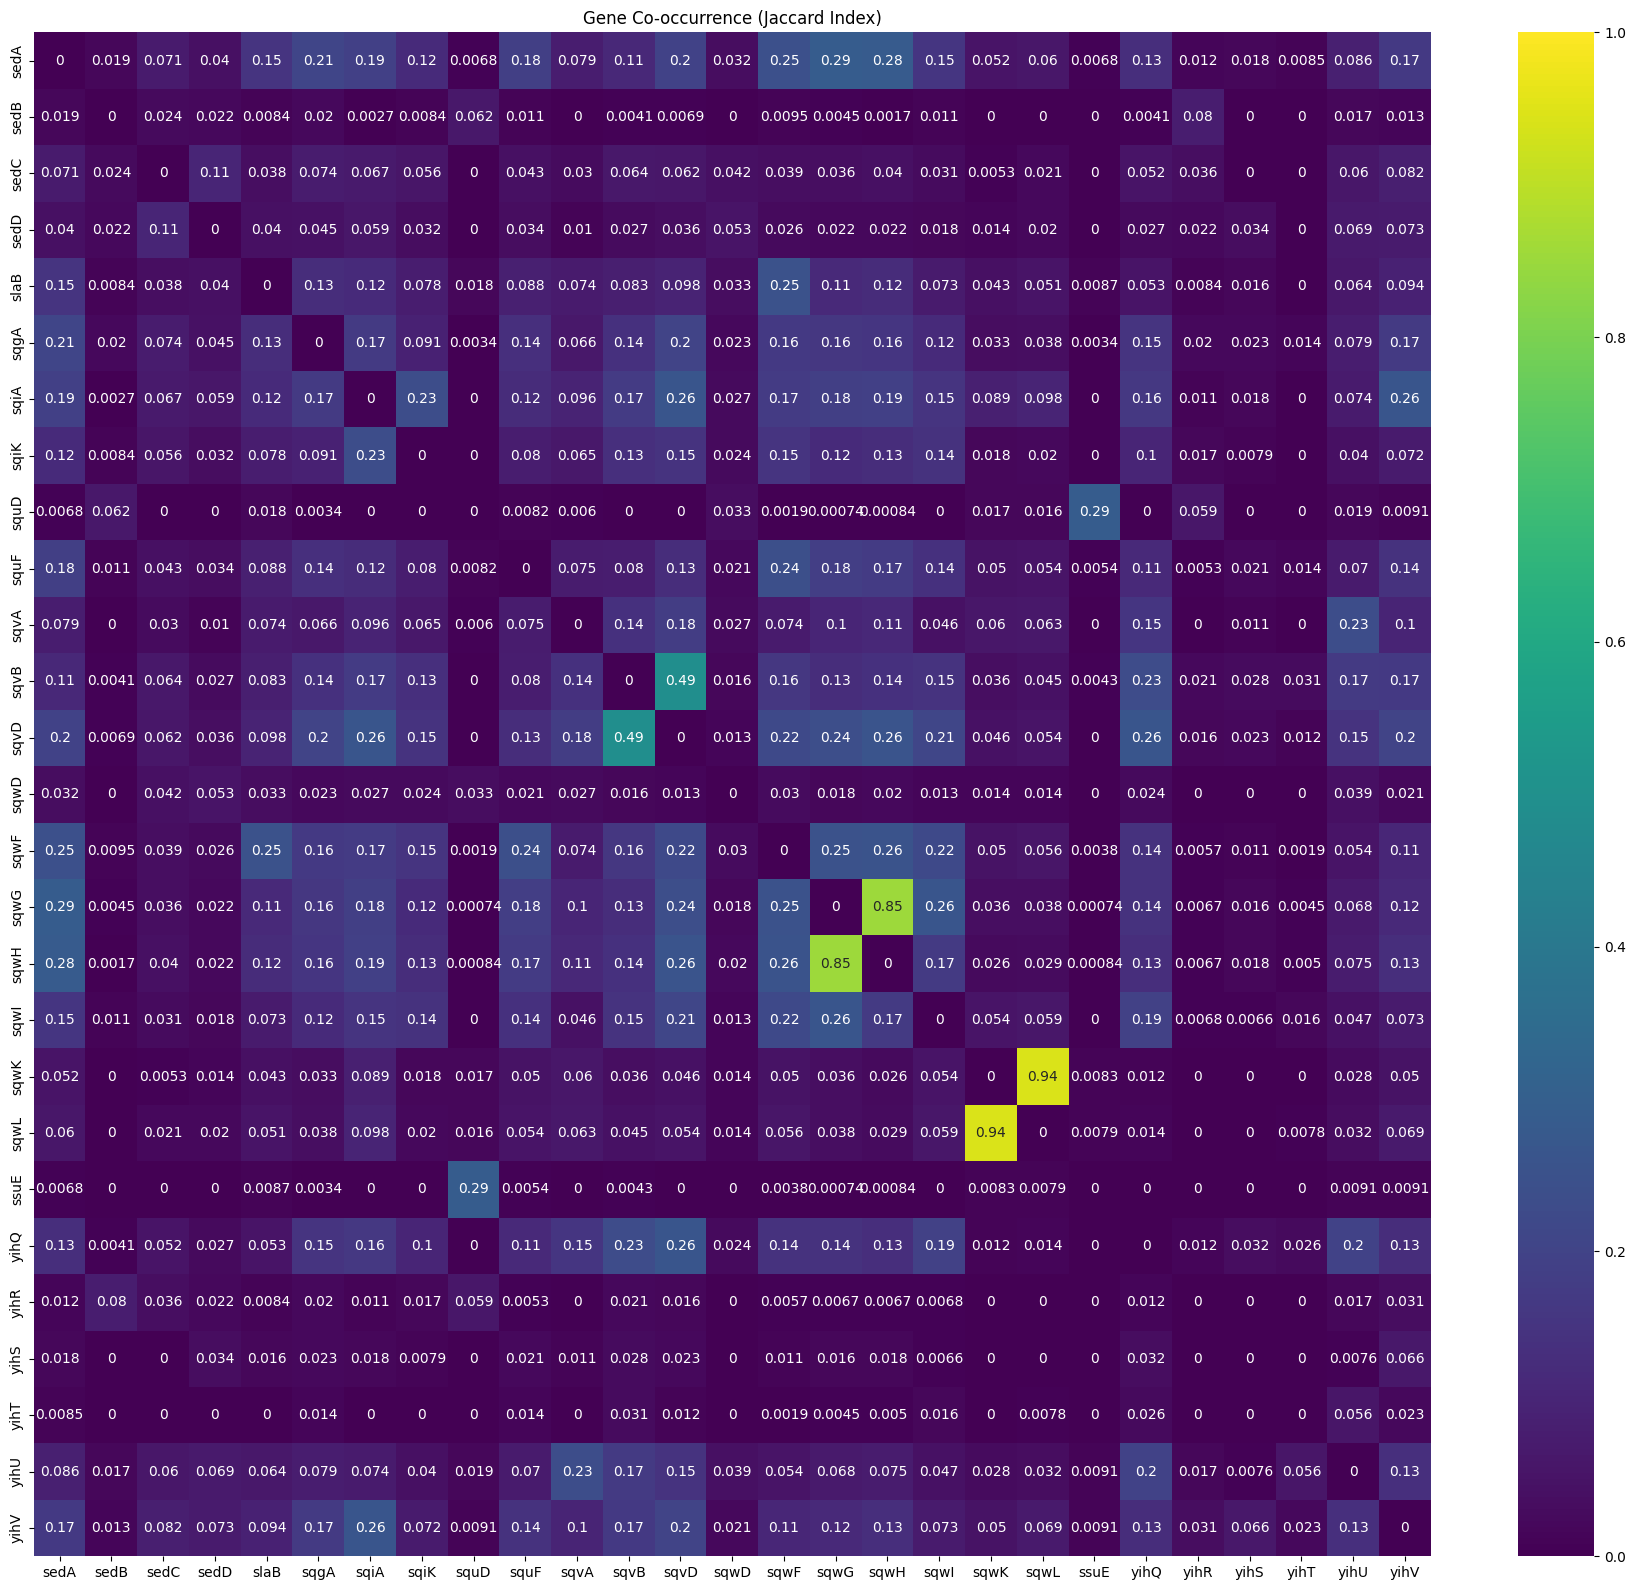

In [11]:
plt.figure(figsize=(18, 16))

sns.heatmap(
    jaccard,
    annot=True,
    cmap="viridis",
    vmin=0,
    vmax=1
)

plt.title("Gene Co-occurrence (Jaccard Index)")
plt.tight_layout()
plt.savefig("heatmap.png", dpi=300)
plt.show()

/home/arseniy/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/home/arseniy/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


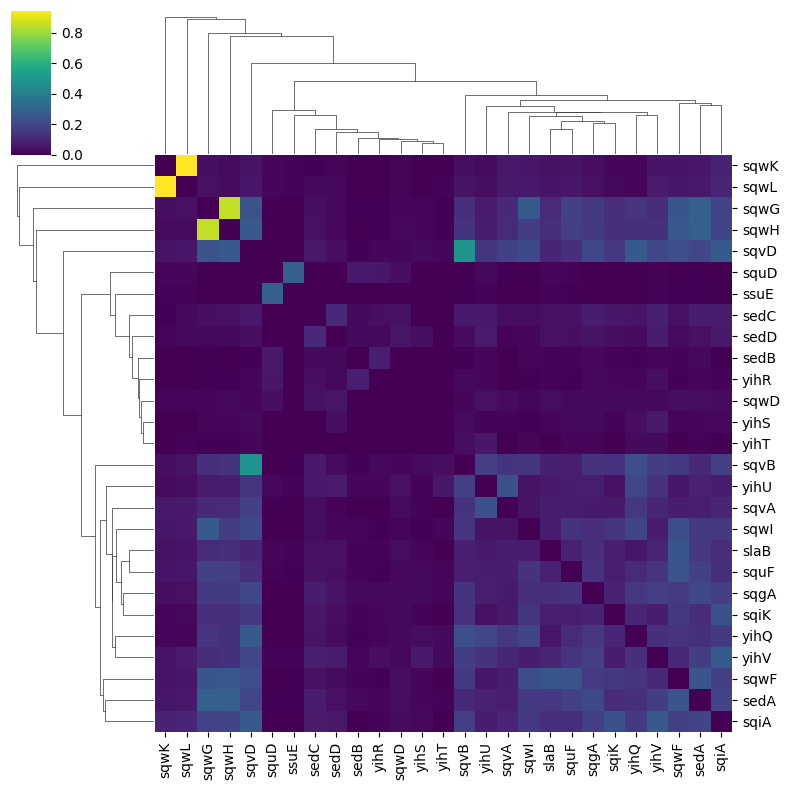

In [12]:
sns.clustermap(
    jaccard,
    cmap="viridis",
    figsize=(8, 8),
    metric="euclidean",
    method="average",
)

/tmp/ipykernel_21771/3766564568.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


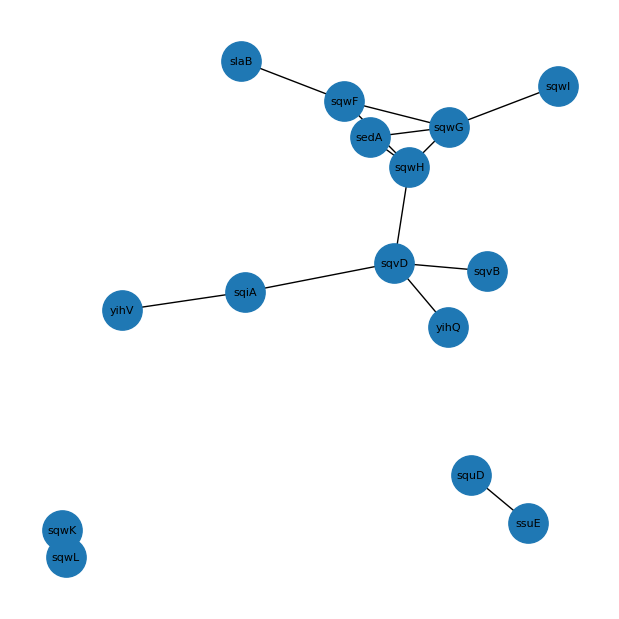

In [18]:
import matplotlib.pyplot as plt
import networkx as nx

G = nx.Graph()

threshold = 0.25

for i in jaccard.index:
    for j in jaccard.columns:
        if i != j and jaccard.loc[i, j] > threshold:
            G.add_edge(i, j, weight=jaccard.loc[i, j])

plt.figure(figsize=(6, 6))

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=800,
    font_size=8
)

plt.tight_layout()
plt.savefig("gene_network.png", dpi=300)
plt.show()

/home/arseniy/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/home/arseniy/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


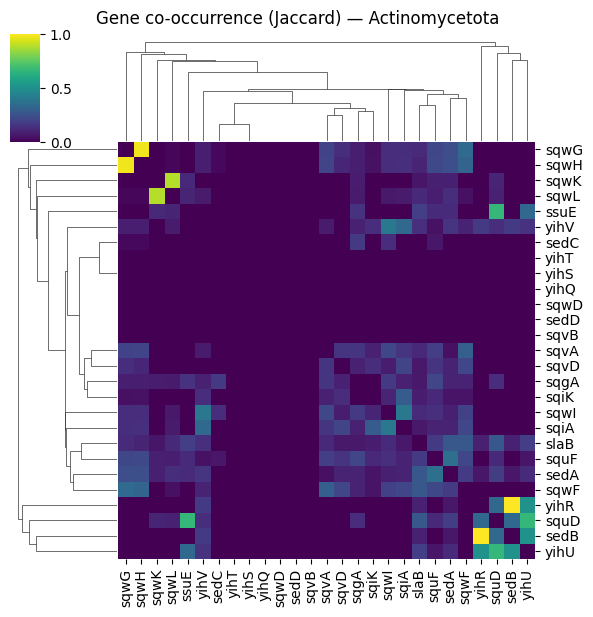

/home/arseniy/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/home/arseniy/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


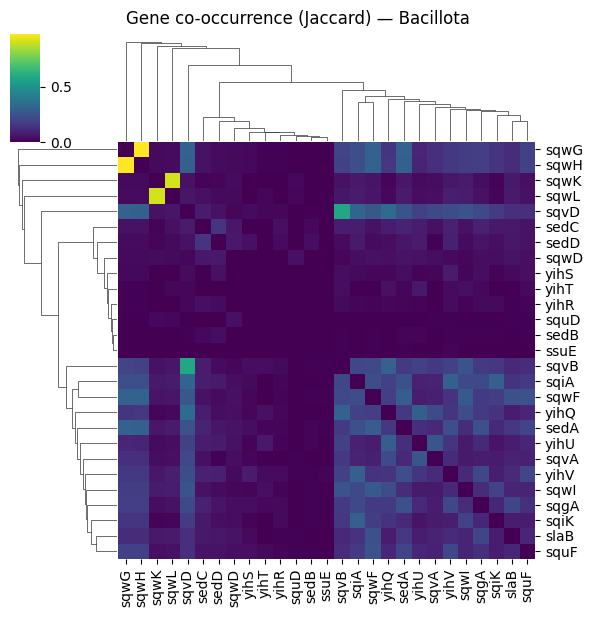

/home/arseniy/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/home/arseniy/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


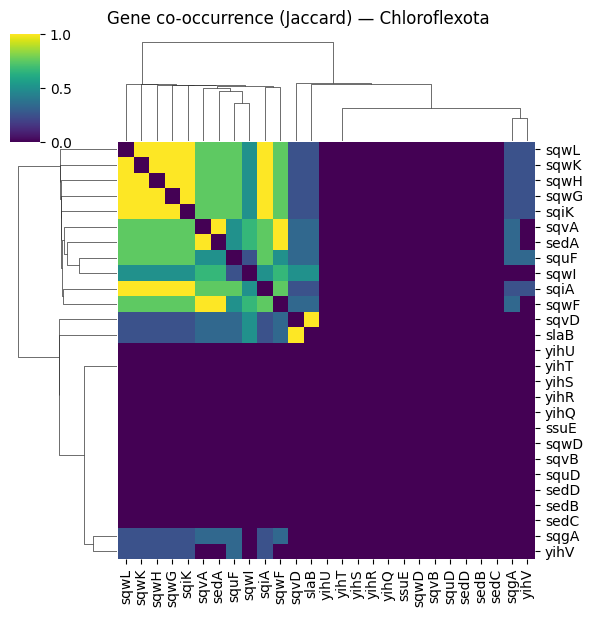

/home/arseniy/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/home/arseniy/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


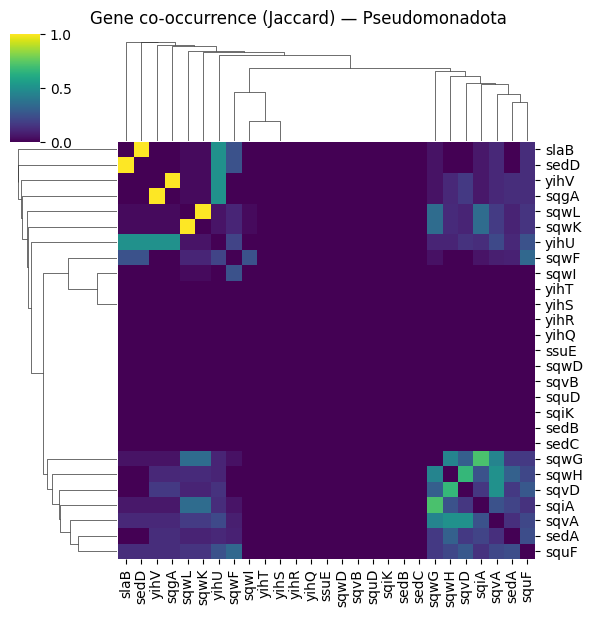

/home/arseniy/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/home/arseniy/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


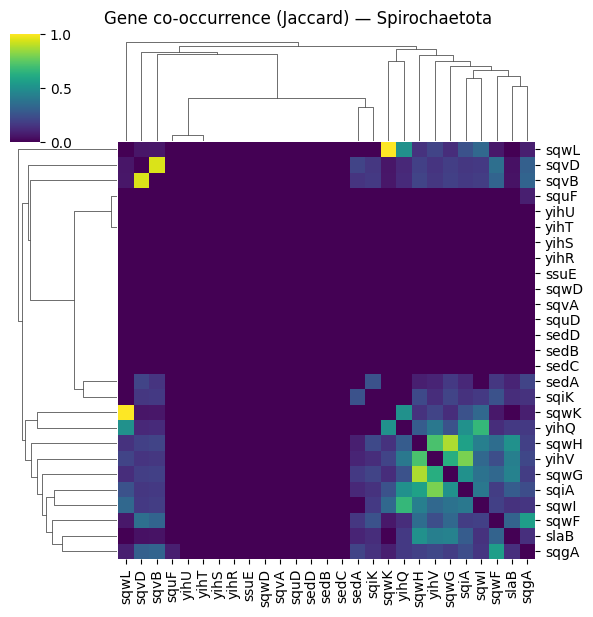

/home/arseniy/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/home/arseniy/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


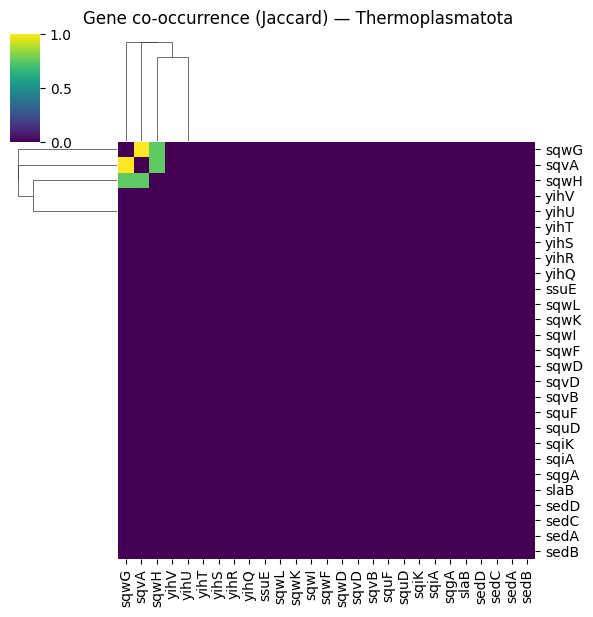

/home/arseniy/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/home/arseniy/miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


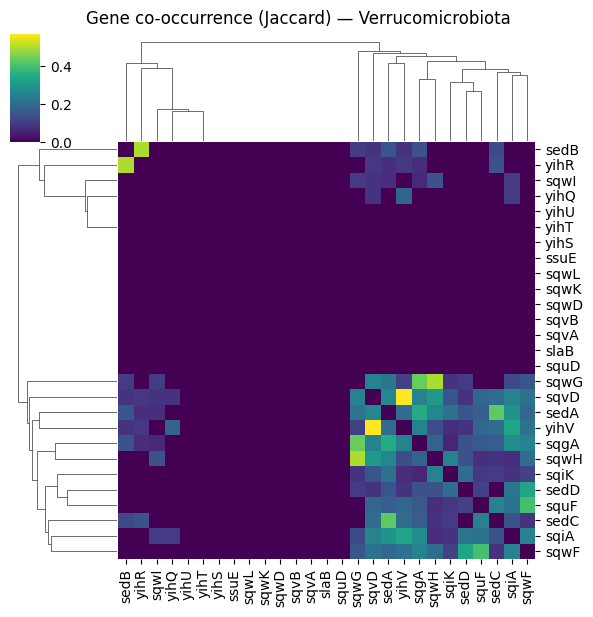

In [14]:
target_phyla = [
    "Actinomycetota",
    "Bacillota",
    "Chloroflexota",
    "Pseudomonadota",
    "Spirochaetota",
    "Thermoplasmatota",
    "Verrucomicrobiota"
]

filtered_matrix = presence_matrix[
    presence_matrix["Phylum"].isin(target_phyla)
]

tax_cols = ["Domain", "Phylum", "Class", "Order", "Family", "Genus", "Species"]

for phylum, group in filtered_matrix.groupby("Phylum"):

    # ----------------------------
    # только гены
    # ----------------------------
    mat = group.drop(columns=tax_cols, errors="ignore")

    if mat.shape[0] < 3:
        print(f"Skipping {phylum} (too few MAGs)")
        continue

    # ----------------------------
    # Jaccard
    # ----------------------------
    intersection = mat.T.dot(mat).values
    counts = mat.sum().values
    union = np.add.outer(counts, counts) - intersection

    union = union.astype(float)
    union[union == 0] = np.nan

    jaccard_phylum = pd.DataFrame(
        intersection / union,
        index=mat.columns,
        columns=mat.columns
    ).fillna(0)

    np.fill_diagonal(jaccard_phylum.values, 0)

    # ----------------------------
    # CLUSTERMAP (ВАЖНО: distance=True)
    # ----------------------------
    g = sns.clustermap(
        jaccard_phylum,
        cmap="viridis",
        figsize=(6, 6),
        method="average",
        xticklabels=1,
        yticklabels=1
    )

    g.fig.suptitle(f"Gene co-occurrence (Jaccard) — {phylum}", y=1.02)

    # ----------------------------
    # SAVE
    # ----------------------------
    filename = f"clustermap_{phylum.replace(' ', '_')}.png"
    g.savefig(filename, dpi=300, bbox_inches="tight")

    plt.show()